# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 12 </span>
## <span style="color:orange"> Keras - Deep & Convolutional Neural Network image recognition </span>

### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

In [2]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

#### Step 1: Load and Process the Data

Keras can conveniently download the MNIST data from the web. All we need to do is import the `mnist` module and use the `load_data()` class, and it will create the training and test data sets or us.

The MNIST set has pre-defined test and training sets, in order to facilitate the comparison of the performance of different models on the data.

Once we have loaded the data, we need to format it in the correct shape.

In [3]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)


#### Reshape data and convert labels to be used with categorical cross entropy

X_train shape: (60000, 784)
X_test shape: (10000, 784)

an example of a data point with label 4


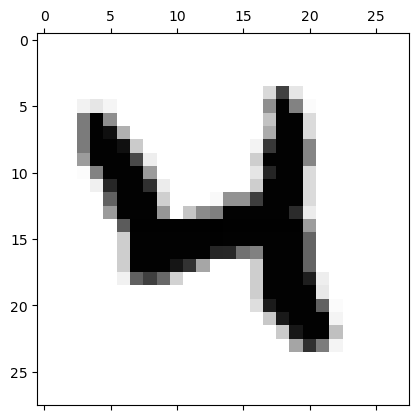

... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical

Y_train shape: (60000, 10)
Y_train shape: (60000, 10)


In [4]:
# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255
X_test /= 255

# look at an example of data point
print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
# `to_categorical` converts this into a matrix with as many columns as there are classes.
# The number of rows stays the same.
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')
print()
print('Y_train shape:', Y_train.shape)
print('Y_train shape:', Y_train.shape)

#### Step 2: Define the Neural Net and its Architecture

We can now move on to construct our deep neural net. We shall use Keras's `Sequential()` class to instantiate a model, and will add different deep layers one by one using the `add()` method

For the purposes of our example, it suffices to focus on `Dense` layers for simplicity. Every `Dense()` layer accepts as its first required argument an integer which specifies the number of neurons. The type of activation function for the layer is defined using the `activation` optional argument, the input of which is the name of the activation function in `string` format. Examples include `relu`, `tanh`, `elu`, `sigmoid`, `softmax`. 

In order for our DNN to work properly, we have to make sure that the numbers of input and output neurons for each layer match. Therefore, we specify the shape of the input in the first layer of the model explicitly using the optional argument `input_shape=(N_features,)`. The sequential construction of the model then allows Keras to infer the correct input/output dimensions of all hidden layers automatically. Hence, we only need to specify the size of the softmax output layer to match the number of categories.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

def create_DNN():
    # instantiate model
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(Dense(400,input_shape=(img_rows*img_cols,), activation='tanh'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


#### Step 3: Choose the Optimizer and the Cost Function

Next, we choose the loss function according to which to train the DNN. For classification problems, this is the cross entropy, and since the output data was cast in categorical form, we choose the `categorical_crossentropy` defined in Keras' `losses` module. Depending on the problem of interest one can pick any other suitable loss function. To optimize the weights of the net, we choose SGD. This algorithm is already available to use under Keras' `optimizers` module, but we could use any other built-in one as well. The parameters for the optimizer, such as `lr` (learning rate) or `momentum` are passed using the corresponding optional arguments of the `SGD()` function. All available arguments can be found in Keras' online documentation at [https://keras.io/](https://keras.io/). While the loss function and the optimizer are essential for the training procedure, to test the performance of the model one may want to look at a particular `metric` of performance. For instance, in categorical tasks one typically looks at their `accuracy`, which is defined as the percentage of correctly classified data points. To complete the definition of our model, we use the `compile()` method, with optional arguments for the `optimizer`, `loss`, and the validation `metric` as follows:

In [6]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model():
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=SGD(),
                  metrics=['acc'])
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


#### Step 4: Train the model

We train our DNN in minibatches. 

Shuffling the training data during training improves stability of the model. Thus, we train over a number of training epochs. Each epoch corresponds to using **all the train data** divided in minibatches.

Training the DNN is a one-liner using the `fit()` method of the `Sequential` class. The first two required arguments are the training input and output data. As optional arguments, we specify the mini-`batch_size`, the number of training `epochs`, and the test or `validation_data`. To monitor the training procedure for every epoch, we set `verbose=True`. 

In [7]:
# training parameters
batch_size = 32
epochs = 5

# create the deep neural net
model_DNN = compile_model()

# train DNN and store training info in history
history = model_DNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=1,
          validation_data=(X_test, Y_test))

c:\Users\pasol\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.7825 - loss: 0.7267 - val_acc: 0.9102 - val_loss: 0.3199
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8817 - loss: 0.4092 - val_acc: 0.9249 - val_loss: 0.2556
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9016 - loss: 0.3427 - val_acc: 0.9343 - val_loss: 0.2226
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9119 - loss: 0.3079 - val_acc: 0.9374 - val_loss: 0.2043
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9192 - loss: 0.2812 - val_acc: 0.9433 - val_loss: 0.1861


#### Step 5: Evaluate the Model Performance on the *Unseen* Test Data

Next, we evaluate the model and read of the loss on the test data, and its accuracy using the `evaluate()` method.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9433 - loss: 0.1861

Test loss: 0.18609312176704407
Test accuracy: 0.9433000087738037


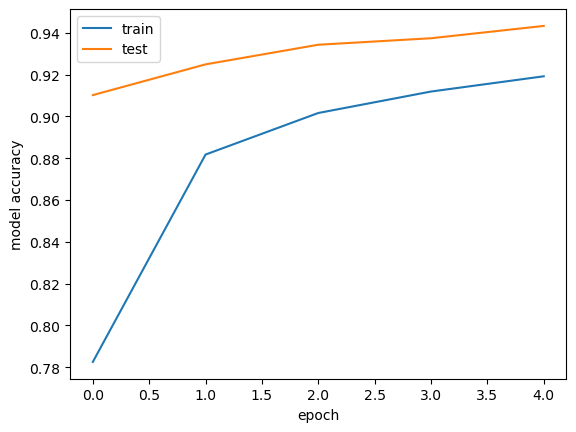

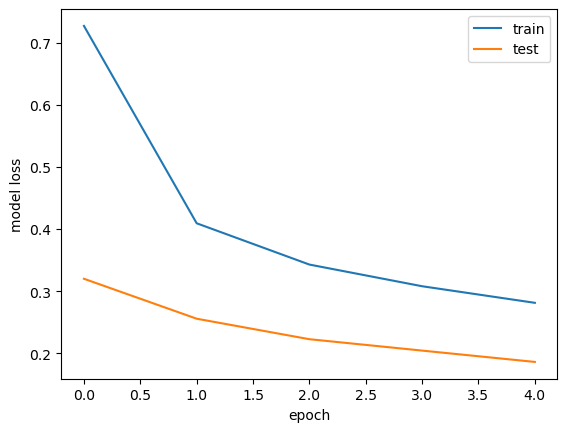

In [8]:
# evaluate model
score = model_DNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

Dropout, during training, slices off some artificial neurons, thus, training accuracy suffers.

Dropout, during testing, turns itself off and allows all of the ‘weak classifiers’ in the neural network to be used. Thus, testing accuracy improves with respect to training accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


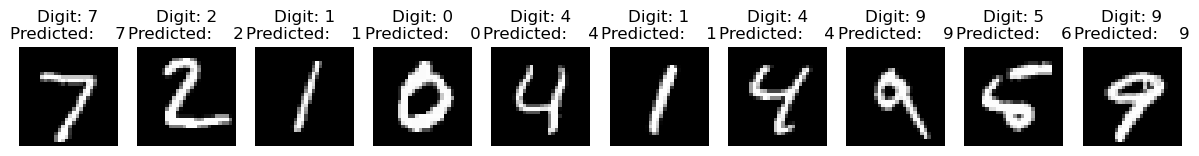

In [9]:
#X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

### Exercise 12.1

<span style="color:red">Change at will and train your DNN by increasing the number of epochs to an adeuqate value</span>. Try to use at least two other optimizers, different from SGD: <span style="color:red">watch to accuracy and loss for training and validation data and comment on the performances</span>.

In [10]:
def compile_model(optimizer):
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])
    return model

In [11]:
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

optimizers = {"SGD":"sgd", "Adam":"adam", "RMSprop":"rmsprop"}

histories = {}  # Per salvare la cronologia delle metriche (loss, acc per epoca)
test_loss = {}  # Per salvare la loss finale sul test set
test_acc = {}  # Per salvare l'accuratezza finale sul test set

for name, opt in optimizers.items():
    print(f"Training {name}")

    model = compile_model(opt)
    history = model.fit(X_train, Y_train,
              batch_size=32,
              epochs=30,
              shuffle=True, # a good idea is to shuffle input before at each epoch
              verbose=1,
              validation_data=(X_test, Y_test))
    histories[name]=history.history
    score = model.evaluate(X_test, Y_test, verbose=1)
    test_loss[name] = score[0]
    test_acc[name] = score[1]

Training SGD
Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.7842 - loss: 0.7201 - val_acc: 0.9099 - val_loss: 0.3205
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8835 - loss: 0.4048 - val_acc: 0.9260 - val_loss: 0.2553
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9020 - loss: 0.3426 - val_acc: 0.9347 - val_loss: 0.2227
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9121 - loss: 0.3073 - val_acc: 0.9401 - val_loss: 0.2008
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9197 - loss: 0.2802 - val_acc: 0.9443 - val_loss: 0.1853
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9241 - loss: 0.2640 - val_acc: 0.9477 - val_loss: 0.1728
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9282 - loss: 0.2497 - val_acc: 0.9504 - val_loss: 0.1631
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9320 - loss: 0.2364 - val_acc: 0.9535 - val_loss: 0.1527
Epoch 9/30
1875/1875 ━━━━━━

Test loss SGD: 0.08598404377698898
Test accuracy SGD: 0.9736999869346619

Test loss Adam: 0.12923482060432434
Test accuracy Adam: 0.9815999865531921

Test loss RMSprop: 0.20498864352703094
Test accuracy RMSprop: 0.9796000123023987



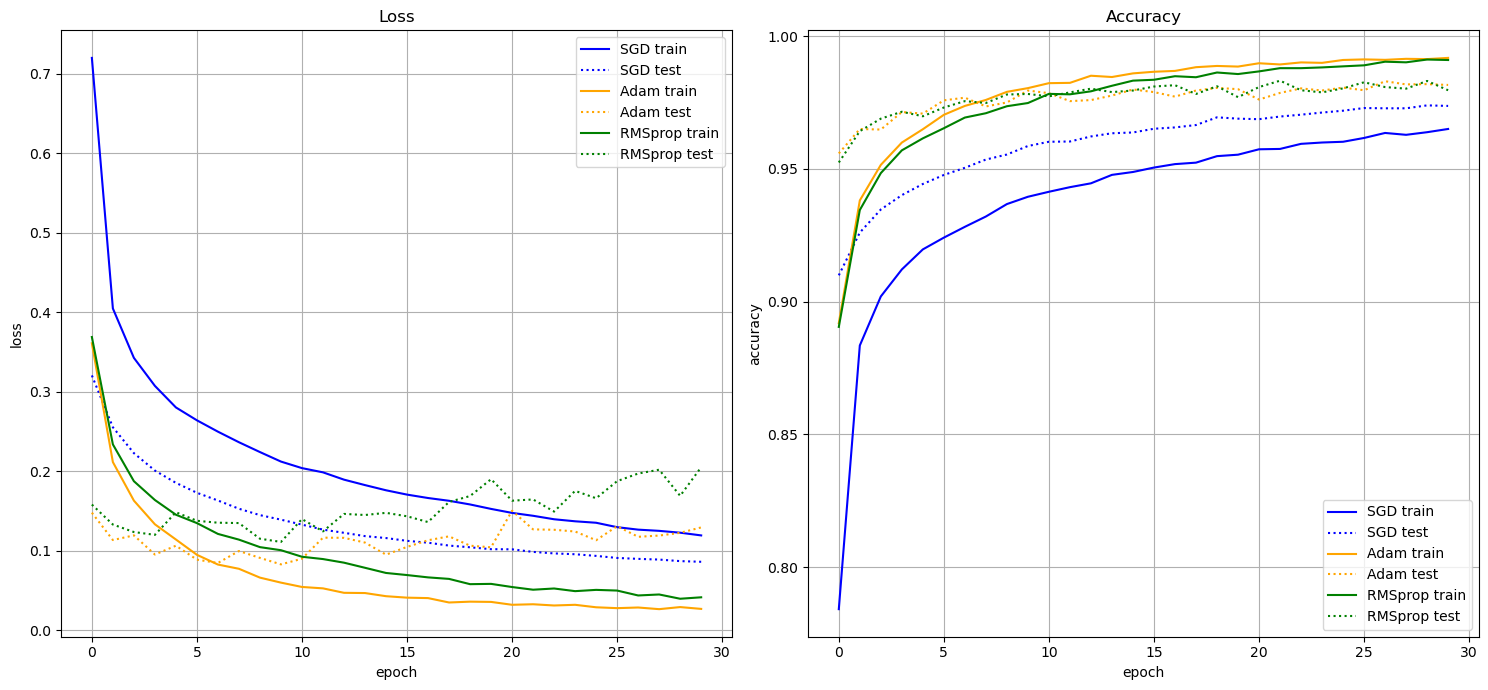

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

colori = {"SGD":"blue", "Adam":"orange", "RMSprop":"green"}

for name, hist in histories.items():
    axs[0].plot(hist["loss"], label=f"{name} train", c=colori[name])
    axs[0].plot(hist["val_loss"], label=f"{name} test", c=colori[name], linestyle=":")
    
    axs[1].plot(hist["acc"], label=f"{name} train", c=colori[name])
    axs[1].plot(hist["val_acc"], label=f"{name} test", c=colori[name], linestyle=":")

    print(f'Test loss {name}: {test_loss[name]}')
    print(f'Test accuracy {name}: {test_acc[name]}\n')

axs[0].set_title("Loss")
axs[0].set_ylabel('loss')
axs[0].set_xlabel('epoch')
axs[0].legend()
axs[0].grid()

axs[1].set_title("Accuracy")
axs[1].set_ylabel('accuracy')
axs[1].set_xlabel('epoch')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

### Commenti
Sono stati testati 3 diversi ottimizzatori con 30 epoche in modo da far convergere asintoticamente lo SGD. Lo Stochastic Gradient Descent si muove nella direzione in cui diminuisce il gradiente e utilizza un tasso di apprendimento fisso per tutti. Adam invece regola automaticamente e in modo dinamico il tasso di apprendimento di ogni singolo parametro basandosi sulla media dei gradienti passati e della loro varianza. Infine, per RMSprop il tasso di apprendimento si regola per ciascun parametro in base all'intensità dei gradienti passati. \
Dai grafici notiamo come l'ottimizzatore Adam sia quello con una miglior train loss, ma se guardiamo l'errore di test l'algoritmo più efficiente resta lo SGD (mentre per la test accuracy i risultati sono simili per tutti e tre).

#### Creating Convolutional Neural Nets with Keras

We have so far considered each MNIST data sample as a $(28\times 28,)$-long 1d vector. On the other hand, we do know that in every one of the hand-written digits there are *local* spatial correlations between the pixels, but also *translational invariance*, which we would like to take advantage of to improve the accuracy of our classification model. To this end, we first need to reshape the training and test input data as follows

In [13]:
# you will need the following for Convolutional Neural Networks
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


One can ask the question of whether a neural net can learn to recognize such local patterns. This can be achieved by using convolutional layers.

### Exercise 12.2

Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end. I have merged step 2 and 3 in the following definition of `create_CNN()` that **<span style="color:red">you should complete</span>**:

In [14]:
def create_CNN():
    # instantiate model
    model = Sequential()
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape))

    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.4))
    model.add(Conv2D(16, kernel_size=(3, 3), activation='relu'))
    model.add(Dropout(0.4))
    model.add(MaxPooling2D(pool_size=(2,2))) 
    model.add(Flatten())
    model.add(Dropout(rate= 0.5))
    model.add(Dense(128, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='SGD',
                  metrics=['acc'])
    return model

Train your DCNN and evaluate its performance proceeding exactly as before:

In [15]:
# training parameters
batch_size = 32
epochs = 15

# create the deep conv net
model_CNN = create_CNN()

# train CNN
history = model_CNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          verbose=1,
          validation_data=(X_test, Y_test))

# evaluate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/15


c:\Users\pasol\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - acc: 0.6429 - loss: 1.0485 - val_acc: 0.9436 - val_loss: 0.2792
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.8903 - loss: 0.3498 - val_acc: 0.9621 - val_loss: 0.1709
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9162 - loss: 0.2739 - val_acc: 0.9680 - val_loss: 0.1382
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9255 - loss: 0.2387 - val_acc: 0.9725 - val_loss: 0.1200
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9334 - loss: 0.2179 - val_acc: 0.9752 - val_loss: 0.1060
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9386 - loss: 0.1999 - val_acc: 0.9767 - val_loss: 0.0927
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9401 - loss: 0.1919 - val_acc: 0.9793 - val_loss: 0.0882
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9451 - loss: 0.1791 - val_acc: 0.9790 - val_loss: 0.0861
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/st

In the end, **<span style="color:red">add the evaluation of your CNN performances</span>** like that used for the DNN.

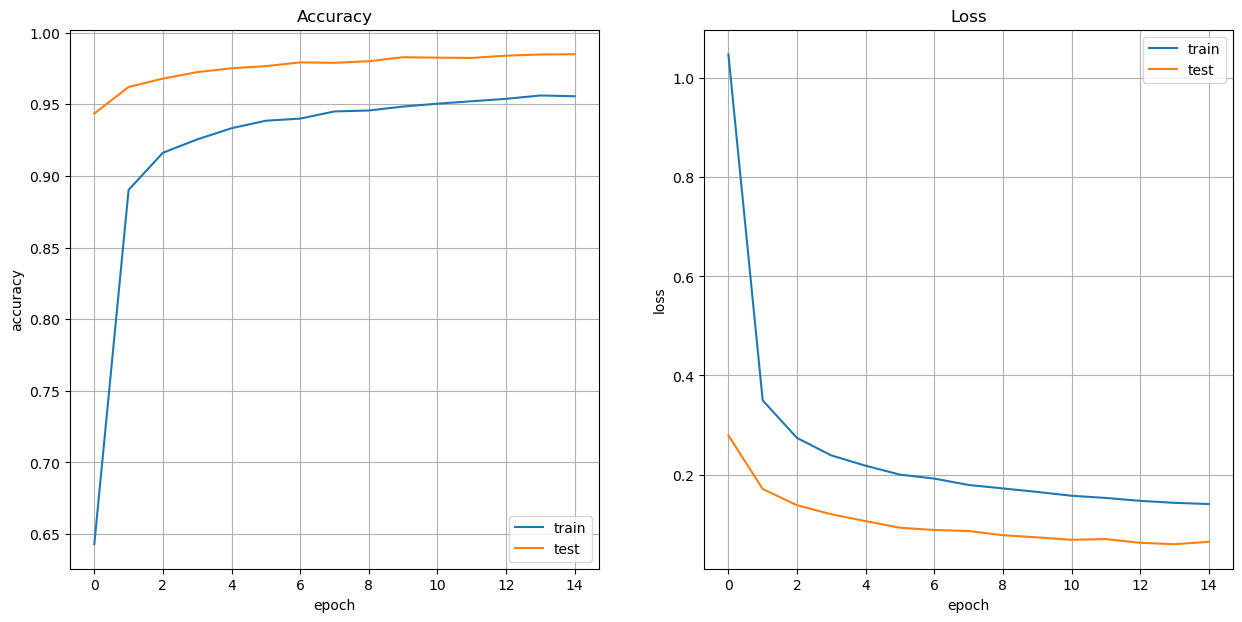

<Figure size 640x480 with 0 Axes>

In [16]:
fig, axs = plt.subplots(1,2, figsize=(15,7))

axs[0].plot(history.history['acc'])
axs[0].plot(history.history['val_acc'])
axs[0].set_ylabel('accuracy')
axs[0].set_xlabel('epoch')
axs[0].set_title('Accuracy')
axs[0].legend(['train', 'test'], loc='best')
axs[0].grid()

axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_ylabel('loss')
axs[1].set_xlabel('epoch')
axs[1].set_title('Loss')
axs[1].legend(['train', 'test'], loc='best')
axs[1].grid()

plt.show()
plt.tight_layout()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


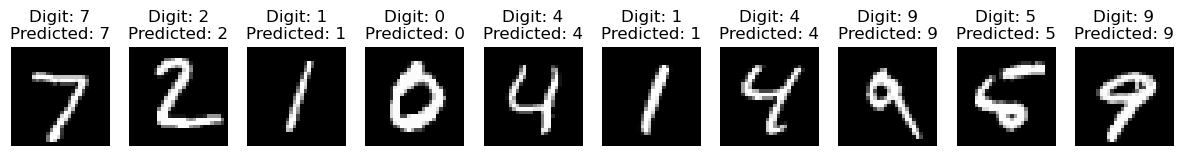

In [17]:
predictions = model_CNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)

plt.figure(figsize=(15, 15))
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i, :, :, 0], cmap="gray")
    plt.title("Digit: {}\nPredicted: {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))
    plt.axis("off")
plt.show()

### Commenti
Ho costruito la rete neurale inserendo un Dropout dopo ciascun layer in modo da evitare l'overfitting. Il risultato mostra una convergenza più rapida rispetto al DNN.

### Exercise 12.3

Use the `gimp` application to create 10 pictures of your "handwritten" digits, import them in your jupyter-notebook and try to see if your CNN is able to recognize your handwritten digits.

For example, you can use the following code to import a picture of an handwritten digit
(Note: you should install Python Image Library (PIL/Pillow):

In [18]:
# TO LOAD FILES ON GOOGLE COLAB
#from google.colab import files
#upload = files.upload() #this will let you browse and choose the file to be uploaded

Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


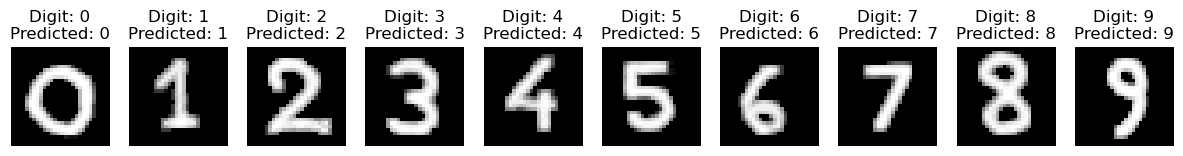

In [21]:
from PIL import Image
import os

plt.figure(figsize=(15,15))

for k in range(10):
    ax = plt.subplot(2,10,k+1)
    digit_filename = f"./numbers/image{k}.png"
    digit_in = Image.open(digit_filename).convert('L')
    ydim, xdim = digit_in.size
    print("Image size: "+str(xdim)+"x"+str(ydim))
    pix=digit_in.load();
    data = np.zeros((xdim, ydim))
#digit_in = Image.open("8b.png").convert('L') #ON GOOGLE COLAB INSERT THE NAME OF THE UPLOADED FILE

    for j in range(ydim):
        for i in range(xdim):
            data[i,j]=pix[j,i]

    data /= 255
    data = data.reshape(1,xdim,ydim,1)
    
    pred_0 = model_CNN.predict(data)
    data = data.reshape(xdim,ydim)

    plt.imshow(data, cmap='gray')    
    plt.title("Digit: {}\nPredicted: {}".format(k,np.argmax(pred_0)))
    plt.axis("off") 
plt.show()

### Commenti
Come si può notare l'algoritmo riesce a predire correttamente tutti i numeri.